In [1]:
# import libraries 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
# load cleaned data
ps = pd.read_csv("exoplanet_volatility_cleaned.csv")
display(ps)

,pl_name,hostname,default_flag,pl_rade,pl_radeerr1,pl_radeerr2,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_eqt,pl_eqterr1,pl_eqterr2,st_teff,st_tefferr1,st_tefferr2,st_rad,st_raderr1,st_raderr2,st_mass,st_masserr1,st_masserr2,pl_rade_unc,pl_orbper_unc,pl_eqt_unc,st_teff_unc,st_rad_unc,st_mass_unc,proxy_habitable
0,AU Mic b,AU Mic,1,4.790000,0.290000,-0.290000,8.463446e+00,5.000000e-06,-5.000000e-06,554.8,31.6,-32.0,3540.0,120.0,-110.0,0.862,0.052,-0.052,0.6350,0.0400,-0.0700,0.290000,5.000000e-06,31.80,0.0520,0.0520,0.0550,0
1,AU Mic c,AU Mic,1,2.790000,0.180000,-0.170000,1.885902e+01,2.200000e-05,-2.400000e-05,424.7,24.2,-24.5,3540.0,120.0,-110.0,0.862,0.052,-0.052,0.6350,0.0400,-0.0700,0.175000,2.300000e-05,24.35,0.0520,0.0520,0.0550,0
2,BD-14 3065 b,BD-14 3065 A,1,21.590000,1.050000,-1.050000,4.288973e+00,5.200000e-06,-5.200000e-06,2001.0,31.0,-31.0,6935.0,90.0,-90.0,2.350,0.080,-0.080,1.4100,0.0500,-0.0500,1.050000,5.200000e-06,31.00,0.0800,0.0800,0.0500,0
3,CFHTWIR-Oph 98 b,CFHTWIR-Oph 98 A,1,20.848704,0.560449,-0.560449,8.040000e+06,4.700000e+05,-4.700000e+05,1800.0,40.0,-40.0,2320.0,40.0,-40.0,0.245,0.007,-0.008,0.0147,0.0008,-0.0008,0.560449,4.700000e+05,40.00,0.0075,0.0075,0.0008,0
4,CoRoT-1 b,CoRoT-1,1,16.700000,0.900000,-0.900000,1.508956e+00,6.400000e-06,-6.400000e-06,1898.0,50.0,-50.0,5950.0,150.0,-150.0,1.110,0.050,-0.050,0.9500,0.1500,-0.1500,0.900000,6.400000e-06,50.00,0.0500,0.0500,0.1500,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1478,Wolf 503 b,Wolf 503,1,2.043000,0.069000,-0.069000,6.001270e+00,2.100000e-05,-2.100000e-05,790.0,15.0,-15.0,4716.0,60.0,-60.0,0.689,0.021,-0.020,0.6880,0.0230,-0.0160,0.069000,2.100000e-05,15.00,0.0205,0.0205,0.0195,0
1479,XO-3 b,XO-3,1,14.795855,0.280225,-0.280225,3.191523e+00,1.400000e-07,-1.400000e-07,1890.0,32.0,-29.0,6970.0,110.0,-100.0,1.523,0.027,-0.027,1.4490,0.0560,-0.0580,0.280225,1.400000e-07,30.50,0.0270,0.0270,0.0570,0
1480,XO-5 b,XO-5,1,12.780000,0.340000,-0.340000,4.187756e+00,6.000000e-07,-6.000000e-07,1230.0,20.0,-20.0,5430.0,70.0,-70.0,1.130,0.030,-0.030,1.0400,0.0300,-0.0300,0.340000,6.000000e-07,20.00,0.0300,0.0300,0.0300,0
1481,XO-6 b,XO-6,1,23.202630,2.465980,-2.465980,3.765001e+00,8.100000e-06,-8.100000e-06,1577.0,28.0,-28.0,6720.0,100.0,-100.0,1.930,0.180,-0.180,1.4700,0.0600,-0.0600,2.465980,8.100000e-06,28.00,0.1800,0.1800,0.0600,0


In [3]:
# central features used for classification
feature_cols = [
    "pl_rade",
    "pl_orbper",
    "pl_eqt",
    "st_teff",
    "st_rad",
    "st_mass"
]

# corresponding uncertainty columns
uncertainty_cols = [
    "pl_rade_unc",
    "pl_orbper_unc",
    "pl_eqt_unc",
    "st_teff_unc",
    "st_rad_unc",
    "st_mass_unc"
]

target_col = "proxy_habitable"

X = ps[feature_cols].copy()
y = ps[target_col].copy()

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nClass Counts:")
print(y.value_counts())

Feature Matrix Shape: (1483, 6)
Target Shape: (1483,)

Class Counts:
proxy_habitable
0    1474
1       9
Name: count, dtype: int64


In [4]:
# train-test split 
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X,
    y,
    ps.index,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)
print("Training Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)
print("\nTraining Class Counts:")
print(y_train.value_counts())
print("\nTest Class Counts:")
print(y_test.value_counts())

Training Set Shape: (1038, 6)
Test Set Shape: (445, 6)

Training Class Counts:
proxy_habitable
0    1032
1       6
Name: count, dtype: int64

Test Class Counts:
proxy_habitable
0    442
1      3
Name: count, dtype: int64


In [5]:
# logistic regression model
log_reg = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight = "balanced", random_state = 42, max_iter = 2000))
])

# train model
log_reg.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [6]:
# random forest model
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ))
])

# train model
rf_model.fit(X_train, y_train)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,300


In [7]:
# test set evaluation 
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    }
    print(f"\n{model_name}")
    print("-" * len(model_name))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    return results

# print results 
log_results = evaluate_model(log_reg, X_test, y_test, "Logistic Regression")
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")
results_df = pd.DataFrame([log_results, rf_results])
results_df


Logistic Regression
-------------------
Confusion Matrix:
[[413  29]
 [  0   3]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.97       442
           1       0.09      1.00      0.17         3

    accuracy                           0.93       445
   macro avg       0.55      0.97      0.57       445
weighted avg       0.99      0.93      0.96       445


Random Forest
-------------
Confusion Matrix:
[[442   0]
 [  1   2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       442
           1       1.00      0.67      0.80         3

    accuracy                           1.00       445
   macro avg       1.00      0.83      0.90       445
weighted avg       1.00      1.00      1.00       445



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.934831,0.09375,1.000000,0.171429
1,Random Forest,0.997753,1.00000,0.666667,0.800000


In [8]:
# baseline predictions for volatility analysis 
ps_test = ps.loc[test_idx].copy()
ps_test["log_reg_pred"] = log_reg.predict(ps_test[feature_cols])
ps_test["rf_pred"] = rf_model.predict(ps_test[feature_cols])
ps_test["log_reg_prob"] = log_reg.predict_proba(ps_test[feature_cols])[:, 1]
ps_test["rf_prob"] = rf_model.predict_proba(ps_test[feature_cols])[:, 1]
ps_test[["pl_name", "proxy_habitable", "log_reg_pred", "rf_pred"]].head()

,pl_name,proxy_habitable,log_reg_pred,rf_pred
246,HD 89345 b,0,0,0
1243,TOI-5388.01,0,1,0
401,K2-260 b,0,0,0
456,K2-316 c,0,1,0
967,TOI-1806.01,0,1,0


In [9]:
# create perturbation function
def perturb_features(df, feature_cols, uncertainty_cols, random_state = None):
    rng = np.random.default_rng(random_state)
    perturbed = df.copy()
    for feature, unc in zip(feature_cols, uncertainty_cols):
        means = df[feature].values
        scales = df[unc].fillna(0).values
        perturbed[feature] = rng.normal(loc = means, scale = scales)
    return perturbed

# monte carlo volatility function
def compute_volatility(model, df, feature_cols, uncertainty_cols, baseline_pred_col, M = 100, seed = 42):
    baseline_preds = df[baseline_pred_col].values
    change_counts = np.zeros(len(df), dtype = int)
    for m in range(M):
        perturbed_df = perturb_features(
            df,
            feature_cols = feature_cols,
            uncertainty_cols = uncertainty_cols,
            random_state = seed + m
        )
        perturbed_preds = model.predict(perturbed_df[feature_cols])
        change_counts += (perturbed_preds != baseline_preds).astype(int)
    volatility_scores = change_counts / M
    return volatility_scores

In [10]:
# compute volatility scores for both models
M = 200 # number of Monte Carlo perturbations
ps_test["log_reg_volatility"] = compute_volatility(
    model = log_reg,
    df = ps_test,
    feature_cols = feature_cols,
    uncertainty_cols = uncertainty_cols,
    baseline_pred_col = "log_reg_pred",
    M = M,
    seed = 42
)
ps_test["rf_volatility"] = compute_volatility(
    model = rf_model,
    df = ps_test,
    feature_cols = feature_cols,
    uncertainty_cols = uncertainty_cols,
    baseline_pred_col = "rf_pred",
    M = M,
    seed = 42
)
ps_test[[
    "pl_name",
    "proxy_habitable",
    "log_reg_pred",
    "rf_pred",
    "log_reg_volatility",
    "rf_volatility"
]].head(10)

,pl_name,proxy_habitable,log_reg_pred,rf_pred,log_reg_volatility,rf_volatility
246,HD 89345 b,0,0,0,0.000,0.0
1243,TOI-5388.01,0,1,0,0.260,0.0
401,K2-260 b,0,0,0,0.000,0.0
456,K2-316 c,0,1,0,0.465,0.0
967,TOI-1806.01,0,1,0,0.405,0.0
963,TOI-1794 b,0,0,0,0.000,0.0
1290,TOI-6086 b,0,0,0,0.000,0.0
511,K2-37 c,0,0,0,0.000,0.0
399,K2-259 b,0,0,0,0.000,0.0
1262,TOI-5713 b,0,1,0,0.000,0.0


In [11]:
# model volatility summaries 
print("Logistic Regression Volatility Summary")
print(ps_test["log_reg_volatility"].describe())
print("\nRandom Forest Volatility Summary")
print(ps_test["rf_volatility"].describe())

# most unstable planets under each model
print("Top 10 most volatile planets - Logistic Regression")
display(
    ps_test[["pl_name", "proxy_habitable", "log_reg_pred", "log_reg_volatility"]]
    .sort_values("log_reg_volatility", ascending = False)
    .head(10)
)
print("Top 10 most volatile planets - Random Forest")
display(
    ps_test[["pl_name", "proxy_habitable", "rf_pred", "rf_volatility"]]
    .sort_values("rf_volatility", ascending = False)
    .head(10)
)

Logistic Regression Volatility Summary
count    445.000000
mean       0.006449
std        0.042152
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.465000
Name: log_reg_volatility, dtype: float64

Random Forest Volatility Summary
count    445.000000
mean       0.002135
std        0.028612
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.485000
Name: rf_volatility, dtype: float64
Top 10 most volatile planets - Logistic Regression


,pl_name,proxy_habitable,log_reg_pred,log_reg_volatility
456,K2-316 c,0,1,0.465
628,Kepler-1801 c,0,0,0.415
967,TOI-1806.01,0,1,0.405
695,Kepler-409 b,0,0,0.260
1243,TOI-5388.01,0,1,0.260
867,TOI-1221 b,0,0,0.200
379,K2-242 b,0,0,0.155
1016,TOI-2136 b,0,1,0.150
661,Kepler-1995 b,0,0,0.100
301,K2-136 d,0,0,0.085


Top 10 most volatile planets - Random Forest


,pl_name,proxy_habitable,rf_pred,rf_volatility
739,Kepler-62 f,1,1,0.485
616,Kepler-1652 b,1,0,0.345
441,K2-288 B b,0,0,0.105
788,LP 890-9 c,1,1,0.015
246,HD 89345 b,0,0,0.000
252,HIP 116454 b,0,0,0.000
464,K2-320 b,0,0,0.000
283,K2-113 b,0,0,0.000
1202,TOI-4794 b,0,0,0.000
1232,TOI-530 b,0,0,0.000


In [12]:
# volatility comparison: true class
print("Average Volatility by True Proxy Habitability Class")
display(ps_test.groupby("proxy_habitable")[["log_reg_volatility", "rf_volatility"]].mean())

# volatility comparison: predicted class (logistic regression)
print("\nAverage Volatility by Predicted Class (Logistic Regression)")
display(ps_test.groupby("log_reg_pred")["log_reg_volatility"].mean())

# volatility comparison: predicted class (random forest)
print("\nAverage Volatility by Predicted Class (Random Forest)")
display(ps_test.groupby("rf_pred")["rf_volatility"].mean())

Average Volatility by True Proxy Habitability Class


,log_reg_volatility,rf_volatility
proxy_habitable,,
0,0.006493,0.000238
1,0.000000,0.281667



Average Volatility by Predicted Class (Logistic Regression)


log_reg_pred
0    0.003438
1    0.045312
Name: log_reg_volatility, dtype: float64


Average Volatility by Predicted Class (Random Forest)


rf_pred
0    0.001016
1    0.250000
Name: rf_volatility, dtype: float64

In [13]:
# count how many features have zero uncertainty for each planet
ps_test["num_zero_uncertainty_features"] = (ps_test[uncertainty_cols] == 0).sum(axis = 1)
display(
    ps_test[[
        "pl_name",
        "num_zero_uncertainty_features",
        "log_reg_volatility",
        "rf_volatility"
    ]]
    .sort_values("num_zero_uncertainty_features", ascending = False)
    .head(15)
)

,pl_name,num_zero_uncertainty_features,log_reg_volatility,rf_volatility
1080,TOI-261.01,5,0.000,0.0
1215,TOI-5082.01,5,0.000,0.0
967,TOI-1806.01,5,0.405,0.0
1194,TOI-4602.01,5,0.000,0.0
873,TOI-1246 b,1,0.000,0.0
927,TOI-1470 c,1,0.000,0.0
14,CoRoT-23 b,1,0.000,0.0
630,Kepler-1834 c,1,0.000,0.0
660,Kepler-1994 b,1,0.000,0.0
637,Kepler-1976 b,1,0.000,0.0


In [14]:
# save per planet testset predictions and volatility scores
ps_test.to_csv("exoplanet_volatility_results.csv", index = False)

# save model performance summary
results_df.to_csv("model_performance_summary.csv", index = False)

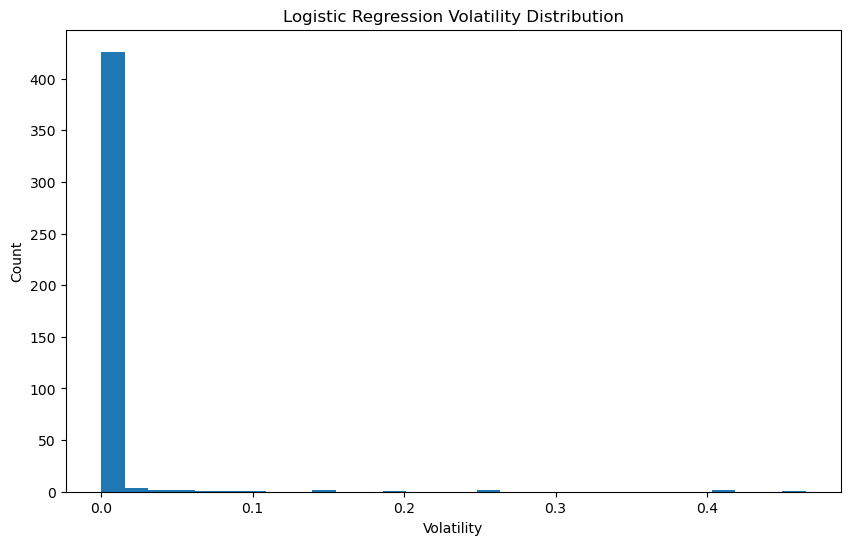

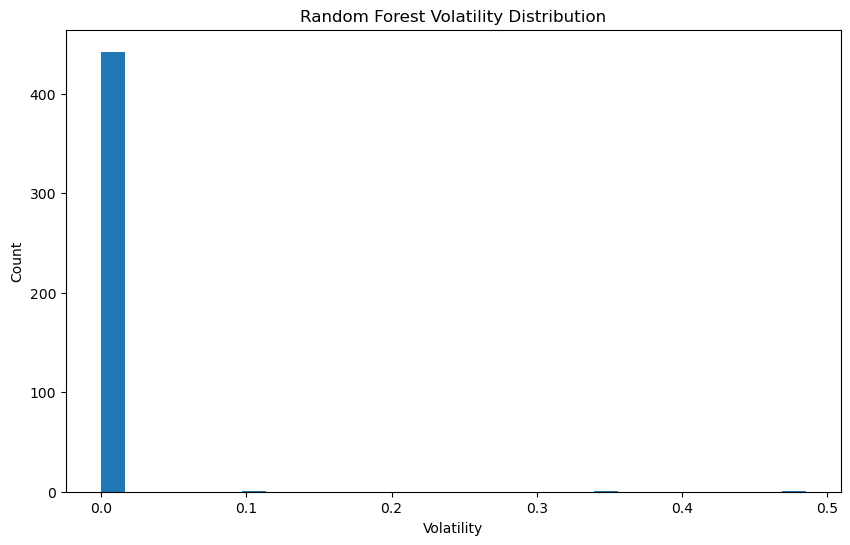

In [18]:
# logistic regression volatility histogram
plt.figure(figsize=(10, 6))
plt.hist(ps_test["log_reg_volatility"], bins=30)
plt.title("Logistic Regression Volatility Distribution")
plt.xlabel("Volatility")
plt.ylabel("Count")
plt.show()

# random forest volatility histogram
plt.figure(figsize=(10, 6))
plt.hist(ps_test["rf_volatility"], bins=30)
plt.title("Random Forest Volatility Distribution")
plt.xlabel("Volatility")
plt.ylabel("Count")
plt.show()

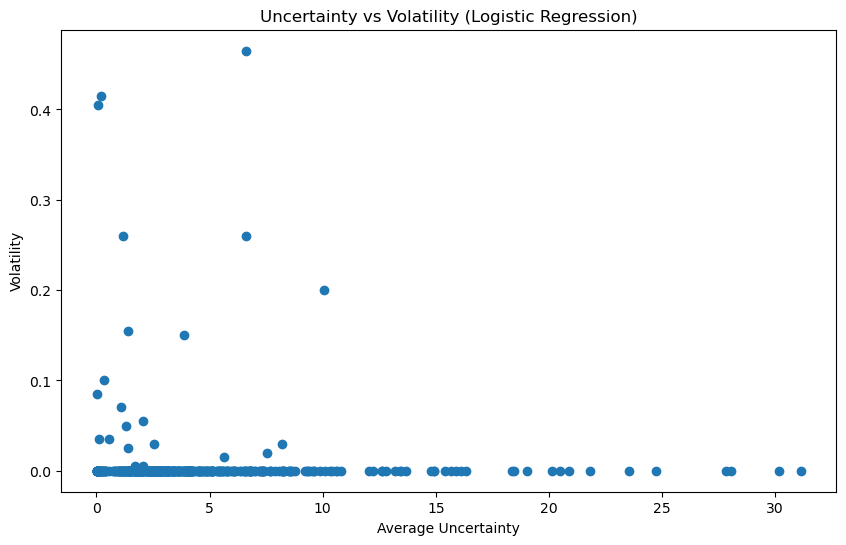

In [19]:
# volatility vs uncertainty
plt.figure(figsize=(10, 6))
ps_test["avg_uncertainty"] = ps_test[uncertainty_cols].mean(axis=1)
plt.scatter(ps_test["avg_uncertainty"], ps_test["log_reg_volatility"])
plt.xlabel("Average Uncertainty")
plt.ylabel("Volatility")
plt.title("Uncertainty vs Volatility (Logistic Regression)")
plt.show()